<a href="https://colab.research.google.com/github/kofisarf/Plant-Disease-Detection-Group-9/blob/main/Plant_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q kaggle

In [3]:
from google.colab import files
files.upload()

{}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip -q plantvillage-dataset.zip -d plantvillage_data

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:20<00:00, 105MB/s]



In [6]:
import os
import shutil

source_dir = 'plantvillage_data/plantvillage dataset/color'

Crop_data = 'Crop_data'

os.makedirs(Crop_data, exist_ok=True)

Study_crops = ['Tomato', 'Corn_(maize)', 'Potato', 'Pepper']

for folder_name in os.listdir(source_dir):
    if any(crop in folder_name for crop in Study_crops):

        src_path = os.path.join(source_dir, folder_name)
        dst_path = os.path.join(Crop_data, folder_name)

        if not os.path.exists(dst_path):
            shutil.copytree(src_path, dst_path)
            print(f"Copied: {folder_name}")

print("Data filtering complete!")

Copied: Potato___Early_blight
Copied: Tomato___Septoria_leaf_spot
Copied: Corn_(maize)___Common_rust_
Copied: Tomato___Early_blight
Copied: Tomato___Leaf_Mold
Copied: Tomato___Tomato_Yellow_Leaf_Curl_Virus
Copied: Tomato___Late_blight
Copied: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Copied: Tomato___healthy
Copied: Potato___Late_blight
Copied: Potato___healthy
Copied: Tomato___Tomato_mosaic_virus
Copied: Tomato___Spider_mites Two-spotted_spider_mite
Copied: Corn_(maize)___healthy
Copied: Pepper,_bell___healthy
Copied: Tomato___Bacterial_spot
Copied: Corn_(maize)___Northern_Leaf_Blight
Copied: Pepper,_bell___Bacterial_spot
Copied: Tomato___Target_Spot
Data filtering complete!


In [7]:
# split-folders helper
!pip install split-folders

import splitfolders

# Split your filtered dataset into train (80%), val (10%), test (10%)
splitfolders.ratio(
    "Crop_data",       # Your filtered folder name
    output="data_split",      # New folder with split subdirectories
    seed=42,
    ratio=(0.8, 0.1, 0.1)
)

print("✅ Data successfully split into train, val, and test folders!")

Copying files: 26639 files [00:04, 5983.03 files/s]

✅ Data successfully split into train, val, and test folders!


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rescale image pixels (from 0-255 down to 0.0-1.0)
datagen = ImageDataGenerator(rescale=1./255)

IMG_SIZE = (128, 128) # Resizing images to 128x128 keeps training fast for Thursday's demo
BATCH_SIZE = 32

# Create the training stream
train_generator = datagen.flow_from_directory(
    'data_split/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Create the validation stream
val_generator = datagen.flow_from_directory(
    'data_split/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Create the testing stream
test_generator = datagen.flow_from_directory(
    'data_split/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 21303 images belonging to 19 classes.
Found 2657 images belonging to 19 classes.
Found 2679 images belonging to 19 classes.


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Get the number of crop classes automatically
num_classes = train_generator.num_classes

# Build a simple baseline CNN architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax') # Outputs probability for each crop disease class
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model for 5 epochs to establish a quick baseline
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
666/666 ━━━━━━━━━━━━━━━━━━━━ 47s 53ms/step - accuracy: 0.7250 - loss: 0.8702 - val_accuracy: 0.8525 - val_loss: 0.4245
Epoch 2/5
666/666 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.8900 - loss: 0.3291 - val_accuracy: 0.8792 - val_loss: 0.3300
Epoch 3/5
666/666 ━━━━━━━━━━━━━━━━━━━━ 30s 45ms/step - accuracy: 0.9372 - loss: 0.1875 - val_accuracy: 0.8792 - val_loss: 0.3740
Epoch 4/5
666/666 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step - accuracy: 0.9647 - loss: 0.1059 - val_accuracy: 0.8796 - val_loss: 0.4184
Epoch 5/5
666/666 ━━━━━━━━━━━━━━━━━━━━ 30s 45ms/step - accuracy: 0.9728 - loss: 0.0795 - val_accuracy: 0.8566 - val_loss: 0.5388


Evaluating baseline model on unseen test data...
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.8604 - loss: 0.5501

Overall Test Accuracy: 86.04%

Generating predictions...
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step

--- Classification Report ---
                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.67      0.63      0.65        52
                       Corn_(maize)___Common_rust_       0.94      1.00      0.97       120
               Corn_(maize)___Northern_Leaf_Blight       0.82      0.89      0.85        99
                            Corn_(maize)___healthy       0.97      0.99      0.98       117
                     Pepper,_bell___Bacterial_spot       0.93      0.66      0.77       101
                            Pepper,_bell___healthy       0.85      0.96      0.90       149
                             Potato___Early_blight       0.82      0.97      0.89       100
           

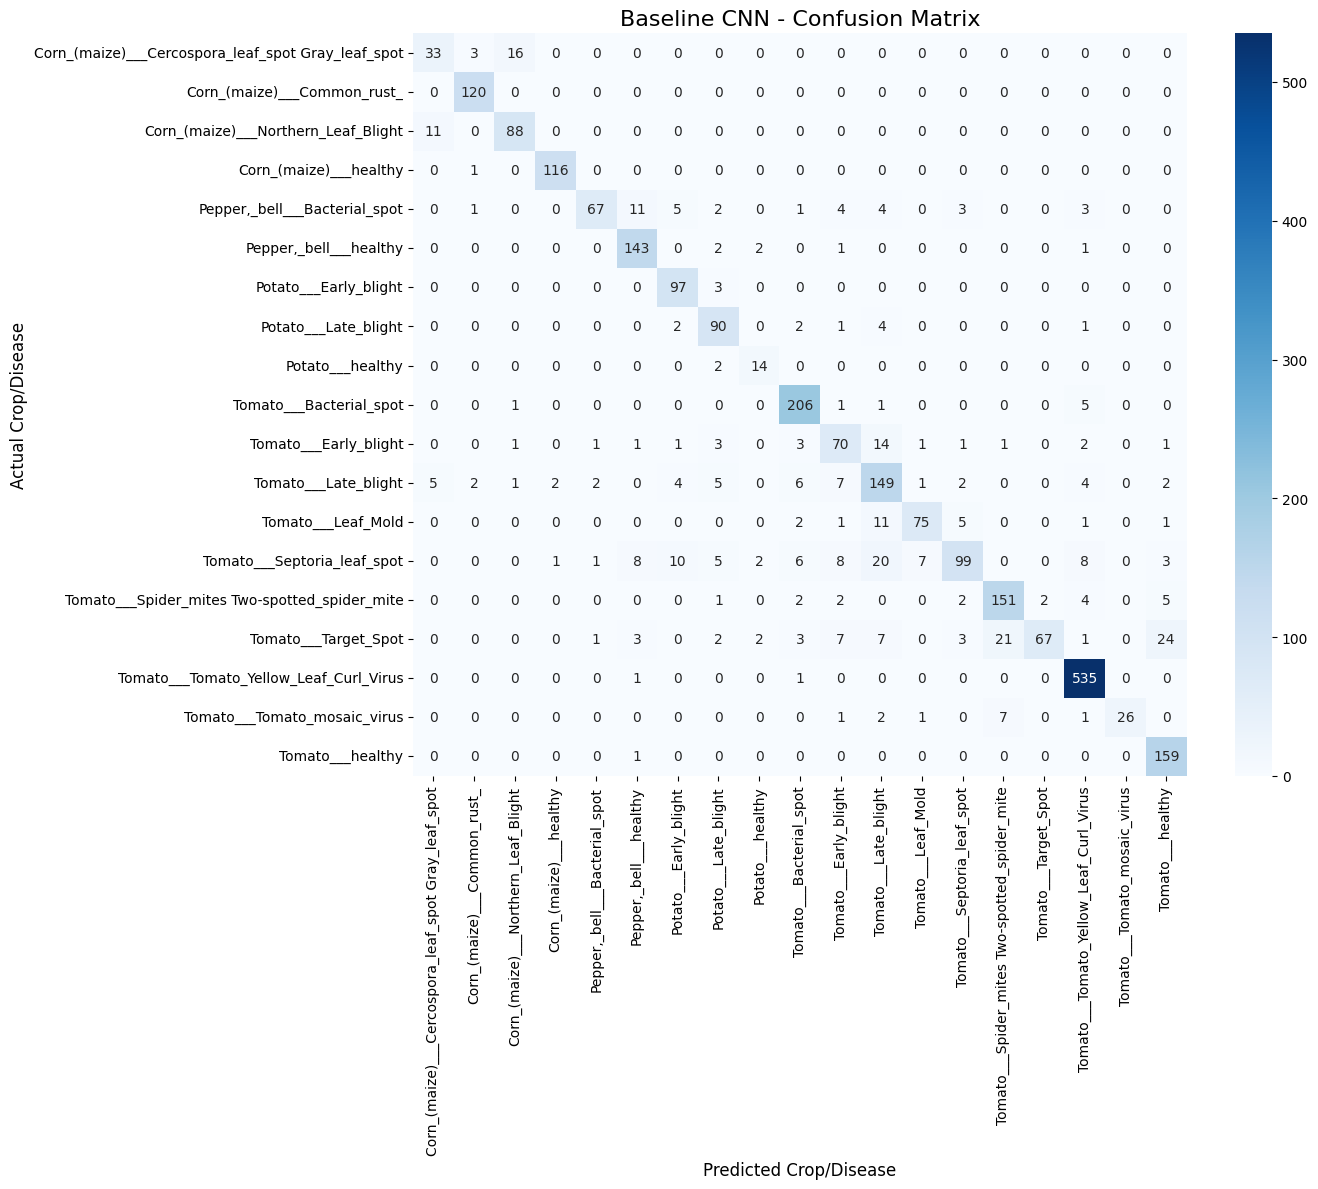

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1.overall accuracy on the test set
print("Evaluating baseline model on unseen test data...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nOverall Test Accuracy: {test_acc * 100:.2f}%\n")

# 2. predictions for the confusion matrix and metrics
# IMPORTANT: Reset the generator to ensure it starts from the very first image
test_generator.reset()
print("Generating predictions...")
predictions = model.predict(test_generator)

# Converting the raw probabilities into final class predictions
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# 3.Generate Precision, Recall, and F1-Score
class_labels = list(test_generator.class_indices.keys())
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_labels))

# 4. Plotting the Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12)) # Make the chart large enough to read the crop names
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Baseline CNN - Confusion Matrix', fontsize=16)
plt.ylabel('Actual Crop/Disease', fontsize=12)
plt.xlabel('Predicted Crop/Disease', fontsize=12)
plt.xticks(rotation=90) # Rotate the labels so they don't overlap
plt.tight_layout()
plt.show()